In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [3]:
data = pd.read_csv('/home/spandan/Documents/sumago/Traffic-Prediction/dataset/feature_engineered_data.csv')
data.head()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,days_of_week,month,day,year,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,291.97,0.0,0.0,1,5097,12,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,False
1,293.23,0.0,0.0,1,4887,13,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,False
2,294.31,0.0,0.0,1,5337,14,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,False
3,295.17,0.0,0.0,1,5692,15,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,False
4,295.13,0.0,0.0,1,6137,16,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,False


In [4]:
x = data.drop(columns=['traffic_volume'])
y = data['traffic_volume']

well we have a time series dataset and if we directly use train test split , sklearn will randomly shuffle and it make that meaningless.

In [5]:
data.index.is_monotonic_increasing

True

In [6]:
data.head(3)

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,days_of_week,month,day,year,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,291.97,0.0,0.0,1,5097,12,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,False
1,293.23,0.0,0.0,1,4887,13,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,False
2,294.31,0.0,0.0,1,5337,14,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,False


In [7]:
data.tail(3)

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,days_of_week,month,day,year,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
48175,282.73,0.0,0.0,90,2159,21,6,9,30,2018,...,False,False,False,False,False,False,False,False,False,True
48176,282.09,0.0,0.0,90,1450,22,6,9,30,2018,...,True,False,False,False,False,False,False,False,False,False
48177,282.12,0.0,0.0,90,954,23,6,9,30,2018,...,True,False,False,False,False,False,False,False,False,False


alr so lets split this manualy

In [8]:
split_idx = int(len(data) * 0.8) #means setting an index value for 80 %

x_train = x.iloc[:split_idx] # go till the 80%th index of the data
x_test = x.iloc[split_idx:] #go from the 80%th index of the data

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]


In [9]:
print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

(38542, 27)
(9636, 27)
(38542,)
(9636,)


lets just make a centralized function to get all evaluation metrices with single function on all regression model

In [10]:
def evaluate(y_true , y_pred):
    mae = mean_absolute_error(y_true , y_pred)
    mse = mean_squared_error(y_true , y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true , y_pred)

    print(f'MAE : {mae}')
    print(f'RMSE : {rmse}')
    print(f'R2 Score : {r2}')
    

# to set a baseline , let me just make 2-3 benchmark setting models to compare to our main models

this model will predict mean traffic for each row

In [11]:

mean_pred = np.full(
    len(y_test),
    y_train.mean()
)
evaluate(y_test, mean_pred)

MAE : 1722.9691418454213
RMSE : 1968.0487249437817
R2 Score : -6.360694378537701e-06


so this is our minimum benchmark

In [12]:
lag_pred = x_test["volume_lag_1h"]

evaluate(y_test, lag_pred)

MAE : 483.5121419676214
RMSE : 737.156090530173
R2 Score : 0.8597024827584416


# Alr now we move to some real models
as we already have our benchmarks set

In [13]:
lrModel = LinearRegression()

In [14]:
lrModel.fit(x_train , y_train)
lrPred = lrModel.predict(x_test)

In [15]:
evaluate(y_test , lrPred)

MAE : 433.7251562876057
RMSE : 607.6644787087946
R2 Score : 0.9046635953104666


the simpelest ML model gave us 90% accuracy , thanks to our extracted features
the 0.91 correlated feature is probably carrying the single model XD

## Random Forest Regressor

In [16]:
rfModel = RandomForestRegressor(n_estimators=100 , random_state=42 , n_jobs=-1)
rfModel.fit(x_train , y_train)
rfPrediction = rfModel.predict(x_test)


In [17]:
evaluate(y_test , rfPrediction)

MAE : 150.5957222914072
RMSE : 235.14929087651993
R2 Score : 0.9857236095785112


random forest took the lead now , 98 r2 score is extreamly well for our project ! 

In [18]:
importance = pd.DataFrame({
    'Columns' : x_train.columns,
    'Importance' : rfModel.feature_importances_
})
importance.sort_values(ascending=False , by = 'Importance').head(15)

,Columns,Importance
10,volume_lag_1h,0.728324
16,hour_cos,0.164310
4,hour,0.057690
15,hour_sin,0.017896
5,days_of_week,0.010183
14,roll_std_24h,0.004569
11,volume_lag_6h,0.004117
13,roll_mean_24h,0.002832
0,temp,0.002772
12,volume_lag_24h,0.001823


so its basically like if you you tell model the traffic 1 hour ago , you will get an accurate prediction!

what i can notice is weather demolished , that dosent even count in top 15s

In [19]:
xgbRegressorModel = XGBRegressor(
     n_estimators=300,
     max_depth=8,
     learning_rate=0.05,
     subsample = 0.8,
     coldsample_bytrees = 0.8,
     random_state = 42,
     n_jobs = -1
)

In [20]:
xgbRegressorModel.fit(x_train , y_train)

/home/spandan/Documents/sumago/Traffic-Prediction/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:02:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "coldsample_bytrees" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [21]:
xgbPredictions = xgbRegressorModel.predict(x_test)

In [22]:
evaluate(y_test , xgbPredictions)

MAE : 151.12832641601562
RMSE : 232.26817239184967
R2 Score : 0.9860712885856628


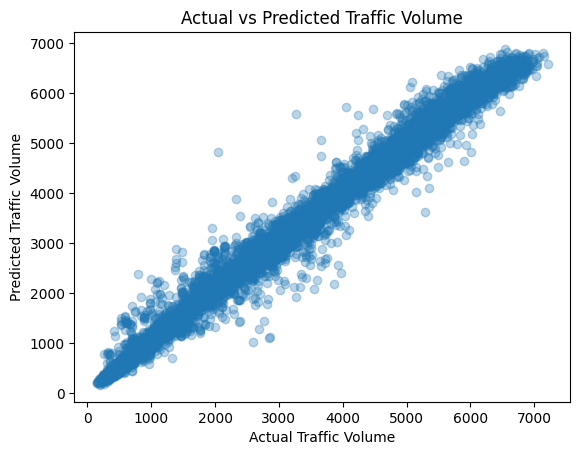

In [23]:
import matplotlib.pyplot as plt

plt.scatter(
    y_test,
    xgbPredictions,
    alpha = 0.3
)
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs Predicted Traffic Volume")
plt.show()

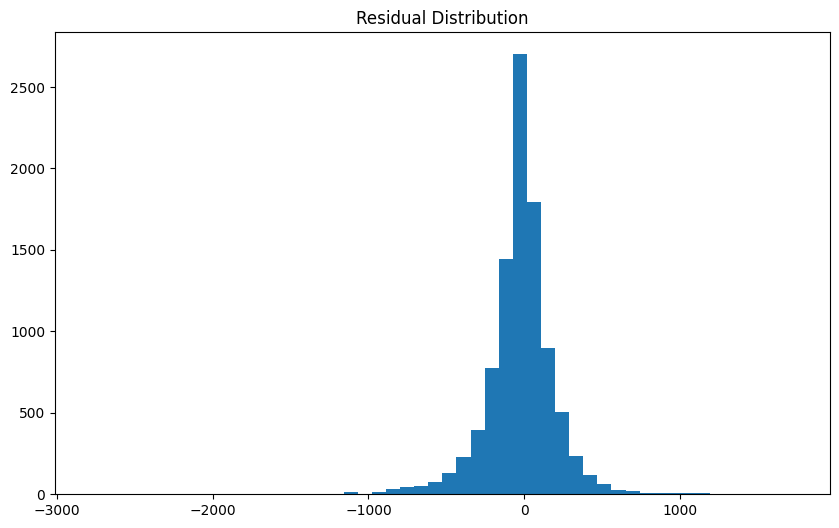

In [24]:
residuals = y_test - xgbPredictions

plt.figure(figsize=(10,6))
plt.hist(residuals, bins=50)

plt.title("Residual Distribution")
plt.show()

all the reseduals are near prediction and thus , the models is actaully a great predictor.